# Simple Instant Policy
## Heterogeneous Graph Representation
After generating the trajectory points, these must be transformed into Heterogeneous Graphs for use with pytorch.
We can define the following objects:
- Nodes:
    - Context nodes: Points of the sample trajectories, whose feature will be the position $(x, y)$.
    - Action nodes: Represent the trajectory that the model is trying to predict. During training these points will be the clean `target`, to which noise will be progressively added.

- Edges (Connectivity):
    - Context $\rightarrow$ Action: Each action node receives information from its nearest context nodes (via k-NN), allowing the trajectory being generated to "see" the demo trajectory.
    - Action $\leftrightarrow$ Action: Bidirectional sequential edges connecting consecutive trajectory points, enabling information flow in both directions for smoothness.

In [1]:
import h5py
import numpy as np
import torch
from torch_geometric.data import HeteroData
from sklearn.neighbors import NearestNeighbors

In [2]:
def normalize_pair(context: np.ndarray, target: np.ndarray):
    """
    Normaliza el par (context, target) conjuntamente al rango [-1, 1].
    usando escalado uniforme para preservar la relación de aspecto.
    """
    # Se apilan verticalmente los arrays en uno
    combined = np.concatenate([context, target], axis=0)
    min_vals = combined.min(axis=0) # Mínimo entre todos los puntos [min_x, min_y]
    max_vals = combined.max(axis=0)
    range_vals = max_vals - min_vals
    # range_vals[range_vals == 0] = 1.0 # Para evitar una división por 0 en el edge case de que el rango sea 0

    # Uniform scaling: use the largest axis range for both
    max_range = range_vals.max()
    if max_range == 0:
        max_range = 1.0 # Para evitar una división por 0 en el edge case de que el rango sea 0

    center = (min_vals + max_vals) / 2.0
    
    context_norm = (context - center) / (max_range / 2.0)
    target_norm  = (target  - center) / (max_range / 2.0)
    return context_norm, target_norm


In [3]:
def build_hetero_graph(
    context: np.ndarray,
    target: np.ndarray,
    k_neighbors: int = 5,
    normalize: bool = True,
) -> HeteroData:
    """
    Convierte un par de trayectorias 2D en un grafo heterogéneo PyG.

    Tipos de nodos:
      - 'context': puntos de la trayectoria de ejemplo (features = posición xy)
      - 'action' : puntos de la trayectoria a predecir (features = posición xy)

    Tipos de aristas:
      - ('context', 'to', 'action'): k-NN, cada action recibe info de sus k context más cercanos
      - ('action', 'to', 'action') : secuencial bidireccional (suavidad de trayectoria)

    Args:
        context:     array (N, 2) con puntos de la trayectoria de ejemplo
        target:      array (N, 2) con puntos de la trayectoria objetivo
        k_neighbors: número de vecinos k-NN para aristas action→context
        normalize:   si True, normaliza el par conjuntamente a [-1, 1]

    Returns:
        HeteroData con nodos y aristas configurados
    """
    if normalize:
        context, target = normalize_pair(context, target)

    data = HeteroData()

    # ── Nodos ────────────────────────────────────────────────────────────────
    # context nodes: features = posición (x, y)
    # Se crea el nodo 'context' y se le asigna su matriz de features: el
    # atributo 'x' en PyTorchGeometric es la matriz de características de los 
    # nodos [num_nodos, num_features]
    # También se convierte el array de numpy a un tensor de PyTorch de punto 
    # flotante de 32 bits para poder operar
    data['context'].x = torch.tensor(context, dtype=torch.float32)

    # action nodes: features = posición (x, y) del target limpio
    # Durante el entrenamiento con difusión, se le añadirá ruido externamente
    data['action'].x = torch.tensor(target, dtype=torch.float32)

    n_context = context.shape[0]  # = 50
    n_action  = target.shape[0]   # = 50

    # ── Aristas: context → action (k-NN) ────────────────────────────────────
    k = min(k_neighbors, n_context) # Para no definir más vecinos que nodos existentes
    knn = NearestNeighbors(n_neighbors=k, algorithm='ball_tree')
    knn.fit(context) # Se "entrena" con los nodos de la trayectoria context
    # Busca los puntos de context más cercano a cada punto de target
    _, indices = knn.kneighbors(target)  # shape: (n_action, k)

    # Construir edge_index: [2, n_action * k]
    # Crea el array de nodos fuente (action). np.arange(50) = [0,1,...,49].
    # np.repeat(..., k) repite cada elemento k veces: [0,0,0,0,0, 1,1,1,1,1, ...,
    # ..., 49,49,49,49,49] si k=5. Cada nodo de acción aparece k veces porque 
    # tiene k aristas salientes.
    dst = np.repeat(np.arange(n_action), k)       # nodos action (fuente)
    # Flatten (50, k) -> (50*k, ) -> Para alinear los índices con src
    src = indices.flatten()                         # nodos context (destino)

    # La clave del tipo de arita es una tupla: (tipo_fuente, relación, tipo_destino)
    data['context', 'to', 'action'].edge_index = torch.tensor(
        # Apila src y dst para crear matriz (2, 50*k). Las aristas deben ser índices
        # enteros (int64). torch.long es el tipo estándar para 'edge_index' en PyG
        np.stack([src, dst], axis=0), dtype=torch.long 
    )

    # ── Aristas: action ↔ action (secuencial bidireccional) ─────────────────
    # Cada nodo se conecta con su predecesor Y su sucesor, permitiendo que
    # la información fluya en ambas direcciones a lo largo de la trayectoria.
    forward_src = np.arange(n_action - 1)       # [0, 1, ..., N-2]
    forward_dst = np.arange(1, n_action)        # [1, 2, ..., N-1]

    src_seq = np.concatenate([forward_src, forward_dst])  # forward + backward
    dst_seq = np.concatenate([forward_dst, forward_src])

    data['action', 'to', 'action'].edge_index = torch.tensor(
        np.stack([src_seq, dst_seq], axis=0), dtype=torch.long
    )

    # ── Aristas: context ↔ context (secuencial bidireccional) ────────────────
    # Preserva el orden de la trayectoria demo para que la GNN
    # entienda la estructura secuencial del contexto.
    fwd_src_ctx = np.arange(n_context - 1)
    fwd_dst_ctx = np.arange(1, n_context)

    src_ctx = np.concatenate([fwd_src_ctx, fwd_dst_ctx])
    dst_ctx = np.concatenate([fwd_dst_ctx, fwd_src_ctx])

    data['context', 'to', 'context'].edge_index = torch.tensor(
        np.stack([src_ctx, dst_ctx], axis=0), dtype=torch.long
    )

    # Devolver el grafo heterogéneo completamente configurado con 2 tipos de nodos y 2
    # tipos de aristas.
    return data


In [4]:
HDF5_PATH = "dataset_instant_policy_2d_v2.h5"

def load_demo_as_graph(hdf5_path: str, demo_key: str, **kwargs) -> HeteroData:
    """Carga una demo del HDF5 y la convierte a HeteroData."""
    # Abrir el archivo HDF5 en modo lectura
    with h5py.File(hdf5_path, 'r') as f:
        # Navega jerárquicamente 'data'->demo_key->'context' y con [:] carga todos los datos
        # del dataset como un array de NumPy. Usar [:] es importante para cargar los datos
        # en memoria y no solo obtener una referencia al dataset.
        context = f['data'][demo_key]['context'][:]  # (50, 2)
        target  = f['data'][demo_key]['target'][:]   # (50, 2)
    return build_hetero_graph(context, target, **kwargs)


# Prueba con la primera demo
graph = load_demo_as_graph(HDF5_PATH, 'demo_491', k_neighbors=5)
# PyG tiene un método de impresión personalizado (__repr__) que muestra un resumen del
# grafo, incluyendo los tipos de nodos, aristas y sus formas. Esto es útil para verificar
# rápidamente la estructura del grafo sin imprimir todos los datos.
print(graph)
print()
print("Nodos context:", graph['context'].x.shape)
print("Nodos action: ", graph['action'].x.shape)
print("Aristas action→context:", graph['context', 'to', 'action'].edge_index.shape)
print("Aristas action→action: ", graph['action', 'to', 'action'].edge_index.shape)


HeteroData(
  context={ x=[8, 2] },
  action={ x=[100, 2] },
  (context, to, action)={ edge_index=[2, 500] },
  (action, to, action)={ edge_index=[2, 198] },
  (context, to, context)={ edge_index=[2, 14] }
)

Nodos context: torch.Size([8, 2])
Nodos action:  torch.Size([100, 2])
Aristas action→context: torch.Size([2, 500])
Aristas action→action:  torch.Size([2, 198])


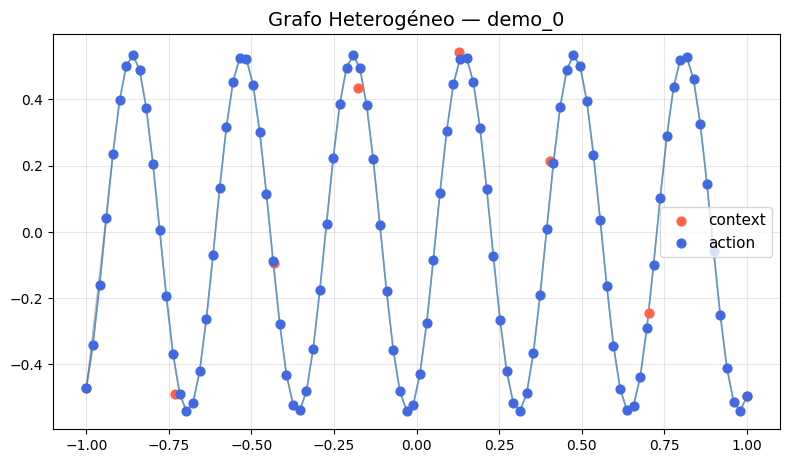

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_hetero_graph(graph: HeteroData, max_edges_shown: int = 5):
    # Convertir de vuelta los tensores a NumPy, para plotear.
    # PyTorch y NumPy comparten memoria cuando el tensor está en CPU -> Conversión gratuita
    ctx = graph['context'].x.numpy() 
    act = graph['action'].x.numpy()
    edge_ac = graph['context', 'to', 'action'].edge_index.numpy()
    edge_aa = graph['action', 'to', 'action'].edge_index.numpy()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    ax.set_title("Grafo Heterogéneo — demo_0", fontsize=14)

    # Aristas action→context (gris, solo las primeras max_edges_shown)
    for i in range(min(max_edges_shown, edge_ac.shape[1])):
        # Desempaqueta los índices de los nodos fuente (action) y destino (context) de
        # la i-ésima arista
        s, d = edge_ac[0, i], edge_ac[1, i]
        # Plotear el segmento
        ax.plot([act[s, 0], ctx[d, 0]], [act[s, 1], ctx[d, 1]],
                color='gray', alpha=0.3, linewidth=0.8, zorder=1)

    # Aristas action→action (azul): Cadena secuencial de la trayectoria objetivo
    for i in range(edge_aa.shape[1]):
        s, d = edge_aa[0, i], edge_aa[1, i]
        ax.plot([act[s, 0], act[d, 0]], [act[s, 1], act[d, 1]],
                color='steelblue', alpha=0.6, linewidth=1.2, zorder=2)

    # Ploteo de nodos: context (tomato) y action (royalblue)
    ax.scatter(ctx[:, 0], ctx[:, 1], c='tomato',  s=40, zorder=3, label='context')
    ax.scatter(act[:, 0], act[:, 1], c='royalblue', s=40, zorder=3, label='action')

    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_hetero_graph(graph, 5)


In [8]:
def iter_dataset_as_graphs(hdf5_path: str, k_neighbors: int = 5):
    """
    Generador que itera sobre todas las demos del HDF5
    y devuelve objetos HeteroData.
    """
    # Abrir con with permite que el archivo se cierre automáticamente al finalizar
    # sin importar si la iteración se completa o se interrumpe por una excepción.
    with h5py.File(hdf5_path, 'r') as f:
        # Obtener la lista de claves de las demos, ordenada alfabéticamente
        demo_keys = sorted(f['data'].keys())
        # Iterar sobre cada demo_key, cargar su context y target, y construir el
        # grafo heterogéneo una a la vez, bajo demanda, sin cargar todo el dataset 
        # en la RAM (Se puede notar por el uso de `yield`). Es un generador
        for key in demo_keys:
            context = f['data'][key]['context'][:]
            target  = f['data'][key]['target'][:]
            yield key, build_hetero_graph(context, target, k_neighbors=k_neighbors)


# Verificación rápida: contar y chequear shapes
count = 0
for key, g in iter_dataset_as_graphs(HDF5_PATH):
    # assert g['context'].x.shape == (100, 2)
    # assert g['action'].x.shape  == (100, 2)
    count += 1

print(f"✅ {count} grafos generados correctamente")


✅ 2000 grafos generados correctamente


# Training
We'll define the noise scheduler (using DDPM - Denoising Diffusion Probabilistic Model) and the training loop.

In [9]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch_geometric.loader import DataLoader
from tqdm.notebook import tqdm # Para una barra de progreso agradable

from src.classes.DDPMScheduler import DDPMScheduler
from src.classes.instant_policy_model import InstantPolicyModel

In [ ]:
# =====================================================================
# 2. El Bucle de Entrenamiento (Training Loop)
# =====================================================================
def train_diffusion_policy(model, train_list, val_list=None, epochs=100, batch_size=32, lr=1e-3, device='cpu'):
    # Usamos el DataLoader específico para grafos de PyG
    # dataloader = DataLoader(dataset_list, batch_size=batch_size, shuffle=True)
    train_loader = DataLoader(train_list, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(train_list, batch_size=batch_size, shuffle=True) if val_list else None
    
    optimizer = AdamW(model.parameters(), lr=lr)
    scheduler = DDPMScheduler(num_timesteps=100)
    
    model = model.to(device)

    train_loss_history = []
    val_loss_history = []

    print(f"Iniciando entrenamiento en {device}...")
    for epoch in range(epochs):
        model.train()   
        total_loss = 0
        
        # Barra de progreso por epoch
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for batch in pbar:
            batch = batch.to(device)
            optimizer.zero_grad()

            # A. Obtener las trayectorias expertas "limpias" (x_0)
            clean_actions = batch['action'].x
            
            # B. Generar ruido gaussiano puro (épsilon)
            noise = torch.randn_like(clean_actions)
            
            # C. Seleccionar un "timestep" aleatorio para cada grafo del batch
            # shape: [batch_size]
            num_graphs = batch.num_graphs
            timesteps = torch.randint(0, scheduler.num_timesteps, (num_graphs,), device=device).long()
            
            # Mapear los timesteps a cada nodo usando el índice de batch
            # node_timesteps shape: [numero_total_de_nodos_en_el_batch]
            node_timesteps = timesteps[batch['action'].batch]

            # D. Contaminar las acciones con el ruido
            noisy_actions = scheduler.add_noise(clean_actions, noise, node_timesteps)

            # E. Ocultar la respuesta correcta:
            # Reemplazamos temporalmente las features del nodo 'action' con la versión ruidosa
            # para que el modelo procese el grafo condicionado al estado ruidoso.
            batch['action'].x = noisy_actions

            # F. Forward Pass: Pedirle al modelo que adivine el RUIDO inyectado
            # (Le pasamos el tensor timesteps [batch_size], y el modelo lo expandirá por nodo)
            predicted_noise = model(batch, timesteps)

            # G. Calcular la pérdida (Mean Squared Error)
            # Queremos que el ruido predicho sea igual al ruido real inyectado
            loss = F.mse_loss(predicted_noise, noise)

            # H. Backpropagation y Optimización
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_loss = total_loss / len(train_loader)
        train_loss_history.append(avg_loss)

        # Validation
        if val_loader is not None:
            model.eval()
            total_val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    clean_actions = batch['action'].x
                    noise = torch.randn_like(clean_actions)
                    num_graphs = batch.num_graphs
                    timesteps = torch.randint(0, scheduler.num_timesteps, (num_graphs,), device=device).long()
                    node_timesteps = timesteps[batch['action'].batch]
                    noisy_actions = scheduler.add_noise(clean_actions, noise, node_timesteps)
                    batch['action'].x = noisy_actions
                    predicted_noise = model(batch, timesteps)
                    loss = F.mse_loss(predicted_noise, noise)
                    total_val_loss += loss.item()
            avg_val_loss = total_val_loss / len(val_loader)
            val_loss_history.append(avg_val_loss)
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.5f}")
    return train_loss_history, val_loss_history

Dado que se armó un generador (iter_dataset_as_graphs), y PyTorch necesita un Dataset tipo lista para hacer el shuffle y el batching, el paso de ejecución se vería así

In [16]:
import random

Iniciando entrenamiento en cpu...


Epoch 1/50:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 1/50 | Avg Loss: 0.29446


Epoch 2/50:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 2/50 | Avg Loss: 0.18491


...

Epoch 48/50 | Avg Loss: 0.10760


Epoch 49/50:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 49/50 | Avg Loss: 0.10628


Epoch 50/50:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 50/50 | Avg Loss: 0.10674


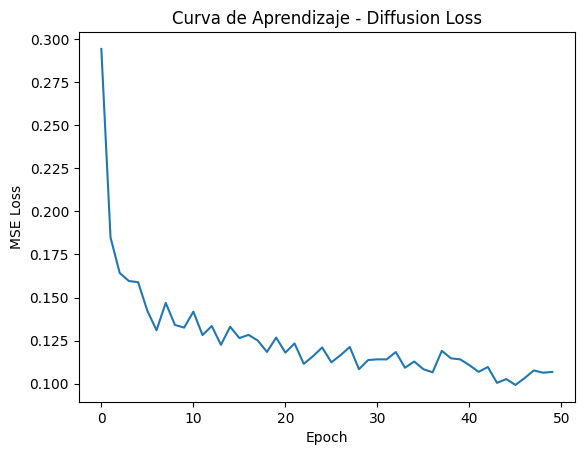

In [ ]:
# 1. Cargar tus datos en una lista en memoria (al ser un PoC pequeño, cabe en RAM)
dataset_list = []
for key, graph in iter_dataset_as_graphs(HDF5_PATH):
    dataset_list.append(graph)

# Separar en train/vale/test
random.seed(42) # Para reproducibilidad
random.shuffle(dataset_list)

n_total = len(dataset_list)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

train_list = dataset_list[:n_train]
val_list = dataset_list[n_train:n_train + n_val]
test_list = dataset_list[n_train + n_val:]

# 2. Instanciar el modelo (que armamos en la Etapa 3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = InstantPolicyModel(metadata=dataset_list[0].metadata(), node_features=2, hidden_dim=64)

# 3. ¡Entrenar!
train_history, val_history = train_diffusion_policy(
    model=model, 
    train_list=train_list,
    val_list=val_list,
    epochs=50, 
    batch_size=16, # Ajusta según la VRAM de tu GPU
    lr=1e-3,
    device=device
)

# Puedes graficar el historial de pérdida para ver cómo converge
import matplotlib.pyplot as plt
plt.plot(train_history, label='Train Loss')
if val_history:
    plt.plot(val_history, label='Val Loss')
plt.title("Curva de Aprendizaje - Diffusion Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [18]:
import torch
import copy
import matplotlib.pyplot as plt

# =====================================================================
# A. Actualización del Scheduler para la Inferencia
# =====================================================================
def ddpm_reverse_step(scheduler, model, current_x, t, graph, device):
    """
    Realiza un único paso de limpieza (denoising) de t a t-1.
    Implementa la fórmula matemática exacta de DDPM.
    """
    t_tensor = torch.tensor([t], device=device, dtype=torch.float32)
    
    # Update action features in-place (graph already cloned by caller)
    graph['action'].x = current_x
    
    # 3. Pedirle a la GNN que prediga el ruido
    with torch.no_grad():
        predicted_noise = model(graph, t_tensor)
        
    # 4. Extraer las constantes matemáticas del scheduler para el paso t
    alpha_t = scheduler.alphas[t].to(device)
    alpha_cumprod_t = scheduler.alphas_cumprod[t].to(device)
    
    # 5. Calcular la parte determinista (restar el ruido predicho)
    # x_{t-1} = (1 / sqrt(alpha_t)) * (x_t - ((1 - alpha_t) / sqrt(1 - alpha_cumprod_t)) * epsilon_theta)
    term1 = 1.0 / torch.sqrt(alpha_t)
    term2 = (1.0 - alpha_t) / torch.sqrt(1.0 - alpha_cumprod_t)
    
    mean_x_t_minus_1 = term1 * (current_x - term2 * predicted_noise)
    
    # 6. Añadir el ruido estocástico z (excepto en t=0)
    if t > 0:
        z = torch.randn_like(current_x)
        # Varianza fija del DDPM (Ho et al., 2020, Eq. 11):
        #   σ²_t = β_t
        # Como alpha_t = 1 - beta_t, entonces:
        #   sqrt(1 - alpha_t) = sqrt(beta_t)
        # Esta es una de las dos opciones válidas del paper original.
        # La otra (varianza posterior) sería:
        #   σ²_t = β_t * (1 - ᾱ_{t-1}) / (1 - ᾱ_t)
        # Una varianza común para sigma_t es simplemente sqrt(1 - alpha_t)
        # o usar la varianza posterior calculada, aquí usamos una simplificación estándar
        sigma_t = torch.sqrt(1.0 - alpha_t)
        x_t_minus_1 = mean_x_t_minus_1 + sigma_t * z
    else:
        x_t_minus_1 = mean_x_t_minus_1 # En el paso final no inyectamos ruido
        
    return x_t_minus_1

# =====================================================================
# B. Función de Generación Completa (Closed-loop Simulation)
# =====================================================================
def generate_trajectory(model, scheduler, context_graph, num_action_nodes=100, device='cpu'):
    """
    Toma un grafo de contexto y genera una trayectoria desde cero
    mediante el proceso reverso de DDPM.
    """
    model.eval()
    
    current_x = torch.randn((num_action_nodes, 2), device=device)
    trajectory_history = [current_x.cpu().numpy()]
    
    # Clone the graph ONCE before the loop (instead of deepcopy per step)
    infer_graph = copy.deepcopy(context_graph).to(device)
    
    print("Iniciando Denoising Process...")
    for t in reversed(range(scheduler.num_timesteps)):
        current_x = ddpm_reverse_step(
            scheduler=scheduler,
            model=model,
            current_x=current_x,
            t=t,
            graph=infer_graph,
            device=device
        )
        if t % 10 == 0 or t == 0:
            trajectory_history.append(current_x.cpu().numpy())
            
    print("¡Trayectoria generada con éxito!")
    return current_x.cpu(), trajectory_history

Iniciando Denoising Process...
¡Trayectoria generada con éxito!


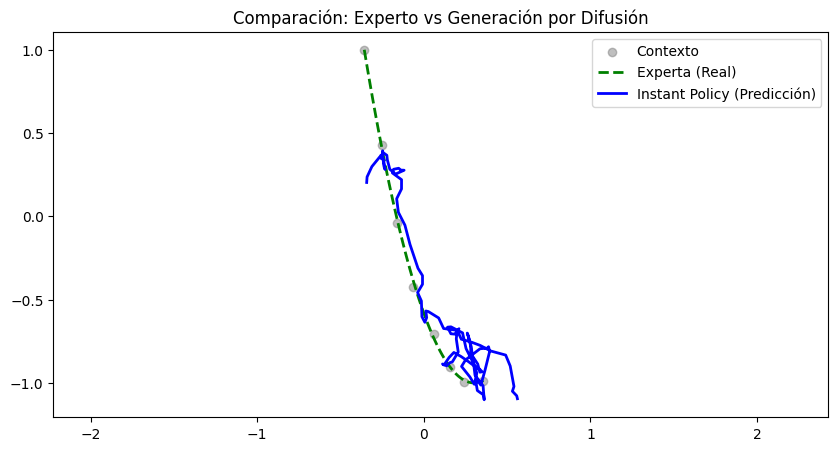

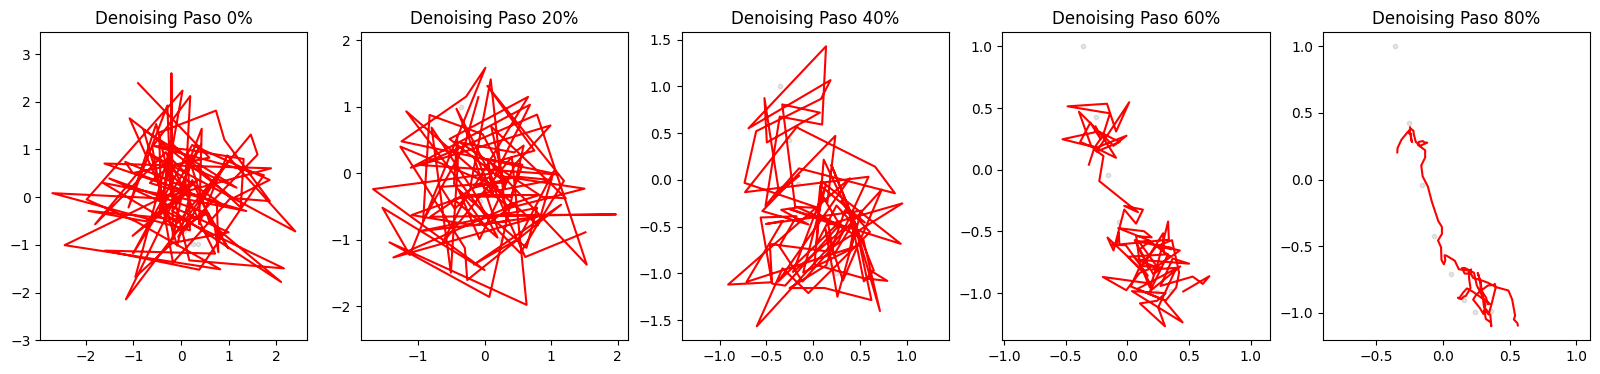

In [19]:
# 1. Preparar el entorno y un grafo de prueba
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Re-instanciamos el scheduler (el mismo de la Etapa 4)
scheduler = DDPMScheduler(num_timesteps=100)

# Tomamos un grafo de prueba (usando el código de tu Etapa 2)
# IMPORTANTE: Asumimos que tienes una función o manera de obtener un grafo. 
# Aquí usaré 'dataset_list[0]' asumiendo que es una lista en memoria.
test_graph = dataset_list[1234] 
experta_x = test_graph['action'].x.clone() # Guardamos la experta para comparar

# 2. Ejecutar la Inferencia
trayectoria_generada, historial = generate_trajectory(
    model=model,
    scheduler=scheduler,
    context_graph=test_graph,
    num_action_nodes=experta_x.shape[0],
    device=device
)

# 3. Visualizar el resultado
plt.figure(figsize=(10, 5))

# Plotear el contexto (Viñedo / Obstáculos)
contexto = test_graph['context'].x.cpu().numpy()
plt.scatter(contexto[:, 0], contexto[:, 1], c='gray', label='Contexto', alpha=0.5)

# Plotear la trayectoria experta original
plt.plot(experta_x[:, 0].numpy(), experta_x[:, 1].numpy(), 'g--', label='Experta (Real)', linewidth=2)

# Plotear la trayectoria predicha por la IA
plt.plot(trayectoria_generada[:, 0].numpy(), trayectoria_generada[:, 1].numpy(), 'b-', label='Instant Policy (Predicción)', linewidth=2)

plt.title("Comparación: Experto vs Generación por Difusión")
plt.legend()
plt.axis('equal')
plt.show()

# 4. (Opcional) Visualizar cómo el ruido se convirtió en trayectoria
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
pasos_a_mostrar = [0, 3, 6, 9, -1] # Índices del historial
for i, ax in enumerate(axes):
    idx = pasos_a_mostrar[i]
    step_data = historial[idx]
    ax.scatter(contexto[:, 0], contexto[:, 1], c='gray', alpha=0.2, s=10)
    ax.plot(step_data[:, 0], step_data[:, 1], 'r-')
    ax.set_title(f"Denoising Paso {i*20}%")
    ax.axis('equal')
plt.show()